<a href="https://colab.research.google.com/github/bedo22/Data-Structures/blob/master/Copy_of_deepfake_XLS_R_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
hahunavth_asvspoof2019_la_path = kagglehub.dataset_download('hahunavth/asvspoof2019-la')

print("Path to dataset files:", hahunavth_asvspoof2019_la_path)


Path to dataset files: /kaggle/input/asvspoof2019-la


In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader
import torchaudio
from torch.optim import AdamW
from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2Model, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_curve
from sklearn.utils import resample
from tqdm.notebook import tqdm
import gc # Garbage collector

In [ ]:
# --- Configuration ---
DATASET_PATH = "/root/.cache/kagglehub/datasets/hahunavth/asvspoof2019-la/versions/1/LA/"
PROTOCOLS_PATH = os.path.join(DATASET_PATH, "ASVspoof2019_LA_cm_protocols")
AUDIO_DIRS = {
    "train": os.path.join(DATASET_PATH, "ASVspoof2019_LA_train/flac"),
    "dev": os.path.join(DATASET_PATH, "ASVspoof2019_LA_dev/flac"),
    "eval": os.path.join(DATASET_PATH, "ASVspoof2019_LA_eval/flac"),
}
PROTOCOL_FILES = {
    "train": os.path.join(PROTOCOLS_PATH, "ASVspoof2019.LA.cm.train.trn.txt"),
    "dev": os.path.join(PROTOCOLS_PATH, "ASVspoof2019.LA.cm.dev.trl.txt"),
    "eval": os.path.join(PROTOCOLS_PATH, "ASVspoof2019.LA.cm.eval.trl.txt"),
}
MODEL_SAVE_PATH = "/kaggle/working/" # Or "./" if running locally
BEST_MODEL_NAME = "wav2vec2_deepfake_best.pt"
FINAL_MODEL_NAME = "wav2vec2_deepfake_final.pt"


In [ ]:
# Model & Training Hyperparameters
MODEL_IDENTIFIER = "facebook/wav2vec2-xls-r-300m"
TARGET_SAMPLE_RATE = 16000 # XLS-R also expects 16kHz
MAX_AUDIO_SECONDS = 5 # Max duration to process
MAX_LENGTH = TARGET_SAMPLE_RATE * MAX_AUDIO_SECONDS

BATCH_SIZE = 16 # Adjust based on GPU memory (XLS-R might require slightly more memory)
EPOCHS = 10 # Initial training epochs
LEARNING_RATE = 5e-3
FINETUNE_EPOCHS = 5
FINETUNE_LR = 2e-5 # Fine-tuning LR might need adjustment for XLS-R
EARLY_STOPPING_PATIENCE = 3
NUM_WORKERS = 2 # Number of parallel data loading workers

In [ ]:
# Data Balancing
SAMPLES_PER_CLASS_TRAIN = 5000
SAMPLES_PER_CLASS_DEV_EVAL = 1250

# Determine device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"Using model: {MODEL_IDENTIFIER}")

# Create output directory if it doesn't exist
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

Using device: cuda
Using model: facebook/wav2vec2-xls-r-300m


In [ ]:
# --- 1. Load Protocol Data & Create Balanced Subset ---
def load_protocol_subset(protocol_path, audio_dir, limit_per_class, balance):
    """Loads protocol, balances classes, and adds full file paths."""
    try:
        # Check if protocol file exists
        if not os.path.exists(protocol_path):
             print(f"Error: Protocol file not found at {protocol_path}")
             return pd.DataFrame(columns=["File_ID", "Label", "filepath"])

        df = pd.read_csv(protocol_path, sep=" ", header=None,
                         names=["Speaker_ID", "File_ID", "-", "Spoof_Type", "Label"])
        df = df[["File_ID", "Label"]]
        df["Label"] = df["Label"].map({"bonafide": 1, "spoof": 0}) # 1 for real, 0 for fake

        df_real = df[df["Label"] == 1]
        df_fake = df[df["Label"] == 0]

        n_real = min(limit_per_class, len(df_real)) if limit_per_class else len(df_real)
        n_fake = min(limit_per_class, len(df_fake)) if limit_per_class else len(df_fake)

        # Only resample if the limit is less than the available samples and samples exist
        df_real_limited = df_real.sample(n=n_real, random_state=42) if n_real < len(df_real) else df_real
        df_fake_limited = df_fake.sample(n=n_fake, random_state=42) if n_fake < len(df_fake) else df_fake

        df_combined = pd.concat([df_real_limited, df_fake_limited])

        # Apply balancing *only* if requested and possible
        if balance:
            print(f"Balancing requested for {os.path.basename(protocol_path)}...")
            min_samples = min(len(df_real_limited), len(df_fake_limited))
            if min_samples > 0: # Ensure there are samples to balance
                 df_real_balanced = resample(df_real_limited, replace=False, n_samples=min_samples, random_state=42)
                 df_fake_balanced = resample(df_fake_limited, replace=False, n_samples=min_samples, random_state=42)
                 df_processed = pd.concat([df_real_balanced, df_fake_balanced]).sample(frac=1, random_state=42) # Shuffle
            else:
                 print("Warning: Cannot balance - one class has 0 samples after limiting.")
                 df_processed = df_combined.sample(frac=1, random_state=42) # Shuffle anyway
        else:
            df_processed = df_combined.sample(frac=1, random_state=42) # Just shuffle

        df_processed['filepath'] = df_processed['File_ID'].apply(lambda x: os.path.join(audio_dir, x + '.flac'))

        # Filter out files that don't exist
        original_count = len(df_processed)
        df_processed = df_processed[df_processed['filepath'].apply(os.path.exists)].reset_index(drop=True)
        filtered_count = len(df_processed)
        if original_count != filtered_count:
            print(f"Warning: {original_count - filtered_count} files not found for {os.path.basename(protocol_path)}.")

        print(f"Loaded {os.path.basename(protocol_path)}: {len(df_processed)} samples total "
              f"({len(df_processed[df_processed['Label']==1])} real, {len(df_processed[df_processed['Label']==0])} fake)")
        return df_processed

    except FileNotFoundError: # Should be caught by os.path.exists, but keep as fallback
        print(f"Error: Protocol file not found at {protocol_path}")
        return pd.DataFrame(columns=["File_ID", "Label", "filepath"])
    except Exception as e:
        print(f"Error loading protocol {protocol_path}: {e}")
        return pd.DataFrame(columns=["File_ID", "Label", "filepath"])

print("Loading protocols...")
# Check if base path exists (useful feedback in Kaggle)
if not os.path.exists(DATASET_PATH):
    print(f"Warning: Base data path not found at {DATASET_PATH}. Check dataset mounting.")
if not os.path.exists(PROTOCOLS_PATH):
     print(f"Warning: Protocols path not found at {PROTOCOLS_PATH}.")


df_train = load_protocol_subset(PROTOCOL_FILES["train"], AUDIO_DIRS["train"], limit_per_class=SAMPLES_PER_CLASS_TRAIN, balance=False)
df_dev = load_protocol_subset(PROTOCOL_FILES["dev"], AUDIO_DIRS["dev"], limit_per_class=SAMPLES_PER_CLASS_DEV_EVAL, balance=True)
df_eval = load_protocol_subset(PROTOCOL_FILES["eval"], AUDIO_DIRS["eval"], limit_per_class=SAMPLES_PER_CLASS_DEV_EVAL, balance=True)

# --- Check if dataframes are empty ---
if df_train.empty or df_dev.empty or df_eval.empty:
    raise ValueError("One or more dataframes (train, dev, eval) are empty. Check data paths and protocol files.")

print("\nTrain subset distribution:")
print(df_train['Label'].value_counts())


Loading protocols...
Loaded ASVspoof2019.LA.cm.train.trn.txt: 7580 samples total (2580 real, 5000 fake)
Balancing requested for ASVspoof2019.LA.cm.dev.trl.txt...
Loaded ASVspoof2019.LA.cm.dev.trl.txt: 2500 samples total (1250 real, 1250 fake)
Balancing requested for ASVspoof2019.LA.cm.eval.trl.txt...
Loaded ASVspoof2019.LA.cm.eval.trl.txt: 2500 samples total (1250 real, 1250 fake)

Train subset distribution:
Label
0    5000
1    2580
Name: count, dtype: int64


In [ ]:
# --- Calculate Class Weights for Training Set ---
print("\nCalculating class weights for training set...")
class_counts = df_train['Label'].value_counts().sort_index()
if len(class_counts) == 2: # Ensure both classes are present
    total_samples = len(df_train)
    weight_for_0 = total_samples / (2.0 * class_counts[0])
    weight_for_1 = total_samples / (2.0 * class_counts[1])
    class_weights = torch.tensor([weight_for_0, weight_for_1], dtype=torch.float)
    print(f"Class weights: {class_weights}")
    class_weights = class_weights.to(DEVICE) # Move weights to the correct device
else:
    print("Warning: Training data does not contain both classes. Cannot calculate weights.")
    class_weights = None # Handle this case in criterion initialization



Calculating class weights for training set...
Class weights: tensor([0.7580, 1.4690])


In [ ]:
# --- 2. PyTorch Dataset ---
class AudioDataset(Dataset):
    """PyTorch Dataset for loading and processing audio files."""
    def __init__(self, dataframe, feature_extractor, target_sr=TARGET_SAMPLE_RATE, max_length=MAX_LENGTH):
        self.df = dataframe
        self.feature_extractor = feature_extractor # Use feature_extractor
        self.target_sr = target_sr
        self.max_length = max_length
        # Pre-create resampler if target_sr is fixed
        self.resampler_cache = {}

    def __len__(self):
        return len(self.df)

    def _get_resampler(self, orig_freq, new_freq):
        """Cache resamplers to avoid recreating them repeatedly."""
        if (orig_freq, new_freq) not in self.resampler_cache:
            self.resampler_cache[(orig_freq, new_freq)] = torchaudio.transforms.Resample(orig_freq=orig_freq, new_freq=new_freq)
        return self.resampler_cache[(orig_freq, new_freq)]

    def __getitem__(self, idx):
        if idx >= len(self.df):
             raise IndexError("Index out of bounds")

        row = self.df.iloc[idx]
        audio_path = row['filepath']
        label = row['Label']

        try:
            waveform, sample_rate = torchaudio.load(audio_path)

            if waveform.shape[0] > 1:
                waveform = torch.mean(waveform, dim=0, keepdim=True)

            if sample_rate != self.target_sr:
                # Use functional resampling which might be slightly faster without caching object
                waveform = torchaudio.functional.resample(waveform, orig_freq=sample_rate, new_freq=self.target_sr)
                # Or use cached resampler:
                # resampler = self._get_resampler(sample_rate, self.target_sr)
                # waveform = resampler(waveform)


            # Truncate or pad waveform
            if waveform.shape[1] > self.max_length:
                waveform = waveform[:, :self.max_length]
            # Padding is handled by the feature extractor's __call__ method

            # Process using the feature extractor
            # Squeeze to remove channel dimension for feature extractor if it's mono
            inputs = self.feature_extractor(
                waveform.squeeze(0),
                sampling_rate=self.target_sr,
                return_tensors="pt",
                padding="max_length", # Pad to a consistent length (model's max or specified max)
                max_length=self.max_length, # Use the same max length for padding
                truncation=True # Ensure truncation if somehow still longer after manual truncate
            )

            # The feature extractor output is nested, get the input_values tensor
            input_values = inputs.input_values.squeeze(0) # Remove batch dim added by feature_extractor

            return {"input_values": input_values, "labels": torch.tensor(label, dtype=torch.long)}

        except Exception as e:
            print(f"Error processing file {audio_path} at index {idx}: {e}")
            # Return None or raise error, or return a dummy sample
            # Returning dummy sample to avoid crashing the loader entirely
            # Adjust dummy shape based on expected feature extractor output if needed
            dummy_input = torch.zeros(self.max_length) # Adjust size if needed
            # Need to process the dummy input to get the correct shape after feature extraction
            dummy_processed = self.feature_extractor(dummy_input, sampling_rate=self.target_sr, return_tensors="pt", padding="max_length", max_length=self.max_length, truncation=True)
            return {"input_values": dummy_processed.input_values.squeeze(0), "labels": torch.tensor(-1, dtype=torch.long)} # Use -1 label for errors


In [ ]:
# --- 3. Initialize Processor and Create Datasets/DataLoaders ---
print(f"Initializing processor for {MODEL_IDENTIFIER}...")
# Load only the feature extractor
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(
    MODEL_IDENTIFIER,
    sampling_rate=TARGET_SAMPLE_RATE # Ensure target sample rate is set
)
print("Creating datasets...")
train_dataset = AudioDataset(df_train, feature_extractor, TARGET_SAMPLE_RATE,MAX_LENGTH)
dev_dataset = AudioDataset(df_dev, feature_extractor, TARGET_SAMPLE_RATE,MAX_LENGTH)
eval_dataset = AudioDataset(df_eval, feature_extractor, TARGET_SAMPLE_RATE,MAX_LENGTH)

# Custom collate function to handle potential errors from __getitem__
def collate_fn(batch):
    batch = [item for item in batch if item is not None and item["labels"] != -1]
    if not batch:
        return None
    try:
        input_values = torch.stack([item["input_values"] for item in batch])
        labels = torch.stack([item["labels"] for item in batch])
        return {
            "input_values": input_values,
            "labels": labels
        }
    except Exception as e:
        print(f"Error during collation: {e}")
        return None


print("Creating data loaders...")
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
                          collate_fn=collate_fn, pin_memory=True, persistent_workers=(NUM_WORKERS > 0))
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                        collate_fn=collate_fn, pin_memory=True, persistent_workers=(NUM_WORKERS > 0))
eval_loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                         collate_fn=collate_fn, pin_memory=True, persistent_workers=(NUM_WORKERS > 0))

print(f"Train loader batches approx: {len(train_loader)}")
print(f"Dev loader batches approx: {len(dev_loader)}")
print(f"Eval loader batches approx: {len(eval_loader)}")


Initializing processor for facebook/wav2vec2-xls-r-300m...
Creating datasets...
Creating data loaders...
Train loader batches approx: 474
Dev loader batches approx: 157
Eval loader batches approx: 157


In [ ]:
# --- 4. Model Definition ---
class XLSRClassificationModel(nn.Module):
    """XLS-R model (Wav2Vec2 architecture) with a classification head."""
    def __init__(self, model_identifier=MODEL_IDENTIFIER, num_labels=2, dropout_prob=0.1):
        super().__init__()
        print(f"Loading pre-trained model: {model_identifier}")
        # Load the pretrained XLS-R base model using Wav2Vec2Model class
        self.xlsr = Wav2Vec2Model.from_pretrained(model_identifier) # <<< Uses updated identifier

        # --- Freeze the encoder initially ---
        self.freeze_encoder() # Call freeze method here

        # Get the hidden size from the model config
        self.hidden_size = self.xlsr.config.hidden_size
        print(f"Model hidden size: {self.hidden_size}")

        # Define the classification head
        self.classifier = nn.Sequential(
            nn.Linear(self.xlsr.config.hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(256, num_labels)
        )
        self.attention_weights_layer = nn.Sequential(
            nn.Linear(self.hidden_size, 128), # Project hidden state
            nn.Tanh(),                     # Activation
            nn.Linear(128, 1)              # Output one score per time step
        )
        self.num_labels = num_labels

    def freeze_encoder(self):
        """Freezes all layers in the feature encoder."""
        print("Freezing encoder layers...")
        if hasattr(self.xlsr, 'feature_extractor'): # Older Wav2Vec2 structure
             for param in self.xlsr.feature_extractor.parameters():
                 param.requires_grad = False
        if hasattr(self.xlsr, 'feature_projection'): # Newer structure / Conv Layers
             for param in self.xlsr.feature_projection.parameters():
                 param.requires_grad = False
        if hasattr(self.xlsr, 'encoder'): # Transformer blocks
            for param in self.xlsr.encoder.parameters():
                param.requires_grad = False
        print("Encoder layers frozen.")

    def unfreeze_encoder(self, num_layers=None):
        """Unfreezes the top 'num_layers' of the transformer encoder."""
        if not hasattr(self.xlsr, 'encoder') or not hasattr(self.xlsr.encoder, 'layers'):
             print("Warning: Model structure does not match expected 'encoder.layers'. Cannot unfreeze specific layers.")
             # Optionally unfreeze the whole encoder if structure is different
             # for param in self.xlsr.encoder.parameters():
             #    param.requires_grad = True
             return

        if num_layers is None: # Unfreeze all encoder layers
            print(f"Unfreezing ALL {len(self.xlsr.encoder.layers)} encoder layers...")
            for param in self.xlsr.encoder.parameters():
                 param.requires_grad = True
        elif num_layers > 0:
             total_layers = len(self.xlsr.encoder.layers)
             layers_to_unfreeze = min(num_layers, total_layers)
             print(f"Unfreezing the top {layers_to_unfreeze} encoder layers...")
             # Unfreeze the specified top layers
             for i in range(total_layers - layers_to_unfreeze, total_layers):
                 for param in self.xlsr.encoder.layers[i].parameters():
                     param.requires_grad = True
        else:
             print("No encoder layers specified to unfreeze (num_layers=0 or None). Keeping frozen.")

        # Optional: Verify which layers are unfrozen
        # for name, param in self.xlsr.encoder.named_parameters():
        #     if param.requires_grad:
        #         print(f"  - Unfrozen: {name}")


    def forward(self, input_values, attention_mask=None):
        # Pass data through base XLS-R model
        outputs = self.xlsr(input_values=input_values, attention_mask=attention_mask)

        # Use the hidden states from the last layer
        last_hidden_state = outputs.last_hidden_state

         # --- Replace Mean Pooling with Attention Pooling ---
        # Calculate attention scores
        attention_logits = self.attention_weights_layer(last_hidden_state).squeeze(-1) # Shape: [batch, seq_len]

        # Apply mask before softmax (mask has 1 for real tokens, 0 for padding)
        if attention_mask is not None:
            # Set scores for padding tokens to a very large negative number
            attention_logits = attention_logits.masked_fill(attention_mask == 0, -1e9)

        # Calculate attention weights
        attention_weights = nn.functional.softmax(attention_logits, dim=1) # Shape: [batch, seq_len]

        # Calculate weighted sum (attention pooling)
        # Unsqueeze weights to match hidden state dims for broadcasting: [batch, seq_len, 1]
        pooled_output = torch.sum(last_hidden_state * attention_weights.unsqueeze(-1), dim=1)
        # Shape: [batch, hidden_size]
        # --- End Replacement ---


        # Pass the pooled output through the classifier
        logits = self.classifier(pooled_output)
        return logits

In [ ]:
# --- 5. EER Calculation ---
def calculate_eer(y_true, y_scores):
    """Calculates the Equal Error Rate (EER)"""
    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores)
    if len(np.unique(y_true)) < 2:
        return float('nan'), float('nan')
    fpr, tpr, thresholds = roc_curve(y_true, y_scores, pos_label=1)
    fnr = 1 - tpr
    eer_threshold_idx = np.nanargmin(np.abs(fpr - fnr))
    if eer_threshold_idx < len(fpr) and eer_threshold_idx < len(fnr):
        eer = (fpr[eer_threshold_idx] + fnr[eer_threshold_idx]) / 2.0
        eer_threshold = thresholds[eer_threshold_idx]
        return eer, eer_threshold
    else:
        print("Warning: Could not determine EER threshold index.")
        return float('nan'), float('nan')

In [ ]:

# --- 6. Training and Evaluation Functions ---
def evaluate(model, data_loader, criterion, device):
    """Evaluates the model on a given dataset."""
    model.eval()
    total_loss = 0.0
    num_samples = 0
    printed_batch_info = False # Flag to print only for the first batch
    with torch.no_grad():
        all_preds = []
        all_labels = []
        progress_bar = tqdm(data_loader, desc="Evaluating", leave=False)
        for i, batch in enumerate(progress_bar): # Add enumerate to track batch index
            if batch is None: continue
            input_values = batch["input_values"].to(device, non_blocking=True)
            labels = batch["labels"].to(device, non_blocking=True).long()
            if input_values.size(0) == 0: continue

            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                logits = model(input_values)
                #labels_one_hot = torch.nn.functional.one_hot(labels, num_classes=2).float()
                #loss = criterion(logits, labels_one_hot)
                loss = criterion(logits, labels)
            total_loss += loss.item() * input_values.size(0)
            num_samples += input_values.size(0)
            probabilities = torch.softmax(logits, dim=1)
            positive_class_probs = probabilities[:, 1].cpu().numpy()
            preds_binary = (positive_class_probs > 0.5).astype(int) # Predicted class
            all_preds.extend(positive_class_probs)
            all_labels.extend(labels.cpu().numpy())

            # --- Add Diagnostic Print ---
            if not printed_batch_info and i == 0: # Print for the first batch only
                print("\n--- Evaluation Batch 0 Diagnostics ---")
                print(f"Labels (first 10): {labels[:10].cpu().numpy()}")
                print(f"Logits (first 5): \n{logits[:5].cpu().numpy()}")
                print(f"Probabilities (first 5): \n{probabilities[:5].cpu().numpy()}")
                print(f"Positive Class Probs (first 10): {positive_class_probs[:10]}")
                print(f"Predicted Binary (first 10): {preds_binary[:10]}")
                print("--- End Diagnostics ---")
                printed_batch_info = True
            # --- End Diagnostic Print ---

    if num_samples == 0: return float('nan'), float('nan'), float('nan')
    avg_loss = total_loss / num_samples
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    eer, _ = calculate_eer(all_labels, all_preds)
    preds_binary = (all_preds > 0.5).astype(int)
    accuracy = np.mean(preds_binary == all_labels) if len(all_labels) > 0 else 0.0
    return avg_loss, accuracy, eer


def train_epoch(model, data_loader, criterion, optimizer, scheduler, device, scaler):
    """Trains the model for one epoch."""
    model.train()
    total_loss = 0.0
    num_batches = 0
    progress_bar = tqdm(data_loader, desc="Training", leave=False)
    for batch in progress_bar:
        if batch is None: continue
        input_values = batch["input_values"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True).long()
        if input_values.size(0) == 0: continue

        optimizer.zero_grad()
        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
            logits = model(input_values)
            #labels_one_hot = torch.nn.functional.one_hot(labels, num_classes=2).float()
            #loss = criterion(logits, labels_one_hot)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        if scheduler: scheduler.step()

        total_loss += loss.item()
        num_batches += 1
        progress_bar.set_postfix({'loss': loss.item()})

    avg_loss = total_loss / num_batches if num_batches > 0 else 0.0
    return avg_loss


def train_model(model, train_loader, dev_loader, criterion, optimizer, scheduler, device, epochs, model_save_path, patience, checkpoint_name):
    """Full training loop with evaluation, checkpointing, and early stopping."""
    best_val_eer = float('inf')
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_eer': []}
    best_model_filepath = os.path.join(model_save_path, checkpoint_name)

    scaler = torch.amp.GradScaler('cuda')

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        train_loss = train_epoch(model, train_loader, criterion, optimizer, scheduler, device, scaler)
        history['train_loss'].append(train_loss)
        print(f"Train Loss: {train_loss:.4f}")

        val_loss, val_acc, val_eer = evaluate(model, dev_loader, criterion, device)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_eer'].append(val_eer)
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val EER: {val_eer:.4f}")

        if not np.isnan(val_eer) and val_eer < best_val_eer:
            best_val_eer = val_eer
            epochs_no_improve = 0
            torch.save(model.state_dict(), best_model_filepath)
            print(f"Validation EER improved to {best_val_eer:.4f}. Saving model to {best_model_filepath}")
        elif not np.isnan(val_eer):
            epochs_no_improve += 1
            print(f"Validation EER did not improve. ({epochs_no_improve}/{patience})")
        else:
            print("Warning: Validation EER is NaN.")

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break

        gc.collect()
        if device == torch.device("cuda"): torch.cuda.empty_cache()

    print("\nTraining loop finished.")
    if os.path.exists(best_model_filepath):
        print(f"Loading best model weights from {best_model_filepath}")
        try:
             model.load_state_dict(torch.load(best_model_filepath, map_location=device))
        except Exception as e:
            print(f"Error loading best model weights: {e}. Continuing with current model state.")
    else:
        print(f"Warning: Best model file '{best_model_filepath}' not found.")
    return history


In [ ]:

# --- 7. Initialize Model, Optimizer, Loss, Scheduler ---
print("Initializing model...")
# <<< CHANGE: Using updated class name >>>
model = XLSRClassificationModel(
    model_identifier=MODEL_IDENTIFIER,
).to(DEVICE)

if class_weights is not None:
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    print("Using CrossEntropyLoss with calculated class weights.")
else:
    criterion = nn.CrossEntropyLoss()
    print("Warning: Using CrossEntropyLoss without class weights (weights could not be calculated).")

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)
num_training_steps = len(train_loader) * EPOCHS
num_warmup_steps = int(0.1 * num_training_steps)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=num_warmup_steps, num_training_steps=num_training_steps)

Initializing model...
Loading pre-trained model: facebook/wav2vec2-xls-r-300m
Freezing encoder layers...
Encoder layers frozen.
Model hidden size: 1024
Using CrossEntropyLoss with calculated class weights.


In [ ]:
# --- 8. Initial Training (Train Classifier Head) ---
print("\n--- Starting Initial Training (Train Classifier Head Only) ---")
history = train_model(
    model, train_loader, dev_loader, criterion, optimizer, scheduler, DEVICE,
    EPOCHS, MODEL_SAVE_PATH, EARLY_STOPPING_PATIENCE,
    checkpoint_name="xlsr_initial_best.pt" # Updated checkpoint name
)


--- Starting Initial Training (Train Classifier Head Only) ---

Epoch 1/10


Training:   0%|          | 0/474 [00:00<?, ?it/s]

Train Loss: 0.5948


Evaluating:   0%|          | 0/157 [00:00<?, ?it/s]


--- Evaluation Batch 0 Diagnostics ---
Labels (first 10): [0 1 1 0 0 1 0 0 1 0]
Logits (first 5): 
[[ 0.2627 -0.3064]
 [-0.51    0.4575]
 [-0.4111  0.3308]
 [-0.3337  0.2532]
 [-0.378   0.31  ]]
Probabilities (first 5): 
[[0.6387 0.3613]
 [0.2754 0.7246]
 [0.3225 0.6772]
 [0.3574 0.6426]
 [0.3345 0.6655]]
Positive Class Probs (first 10): [0.3613 0.7246 0.6772 0.6426 0.6655 0.6367 0.637  0.2893 0.5693 0.64  ]
Predicted Binary (first 10): [0 1 1 1 1 1 1 0 1 1]
--- End Diagnostics ---
Val Loss: 0.5455, Val Acc: 0.8260, Val EER: 0.1632
Validation EER improved to 0.1632. Saving model to /kaggle/working/xlsr_initial_best.pt

Epoch 2/10


...


--- Evaluation Batch 0 Diagnostics ---
Labels (first 10): [0 1 1 0 0 1 0 0 1 0]
Logits (first 5): 
[[ 0.1293 -0.1421]
 [-0.3564  0.4006]
 [-1.059   0.996 ]
 [-0.9683  1.007 ]
 [-0.1295  0.1624]]
Probabilities (first 5): 
[[0.5674 0.4326]
 [0.3193 0.6807]
 [0.1136 0.886 ]
 [0.1218 0.878 ]
 [0.4275 0.5723]]
Positive Class Probs (first 10): [0.4326   0.6807   0.886    0.878    0.5723   0.729    0.772    0.009544
 0.9097   0.2668  ]
Predicted Binary (first 10): [0 1 1 1 1 1 1 0 1 0]
--- End Diagnostics ---
Val Loss: 0.2845, Val Acc: 0.8844, Val EER: 0.1148
Validation EER did not improve. (2/3)

Epoch 10/10


Training:   0%|          | 0/474 [00:00<?, ?it/s]

Train Loss: 0.2359


Evaluating:   0%|          | 0/157 [00:00<?, ?it/s]


--- Evaluation Batch 0 Diagnostics ---
Labels (first 10): [0 1 1 0 0 1 0 0 1 0]
Logits (first 5): 
[[-0.4695  0.4395]
 [-0.947   0.972 ]
 [-1.324   1.23  ]
 [-1.229   1.253 ]
 [-0.6426  0.6543]]
Probabilities (first 5): 
[[0.287   0.713  ]
 [0.1279  0.872  ]
 [0.0721  0.9277 ]
 [0.07715 0.923  ]
 [0.2147  0.785  ]]
Positive Class Probs (first 10): [0.713   0.872   0.9277  0.923   0.785   0.89    0.8716  0.03018 0.9526
 0.509  ]
Predicted Binary (first 10): [1 1 1 1 1 1 1 0 1 1]
--- End Diagnostics ---
Val Loss: 0.2471, Val Acc: 0.8836, Val EER: 0.0984
Validation EER improved to 0.0984. Saving model to /kaggle/working/xlsr_initial_best.pt

Training loop finished.
Loading best model weights from /kaggle/working/xlsr_initial_best.pt


In [ ]:
# --- 9. Fine-tuning ---
print("\n--- Starting Fine-tuning ---")
# Unfreeze encoder layers (e.g., last 4)
model.unfreeze_encoder(num_layers=8)
model.to(DEVICE) # Ensure model is on correct device

# Optimizer for fine-tuning (includes newly unfrozen layers)
optimizer_ft = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=FINETUNE_LR)
num_training_steps_ft = len(train_loader) * FINETUNE_EPOCHS
num_warmup_steps_ft = int(0.1 * num_training_steps_ft)
scheduler_ft = get_linear_schedule_with_warmup(optimizer_ft, num_warmup_steps=num_warmup_steps_ft, num_training_steps=num_training_steps_ft)

# Fine-tune the model
history_ft = train_model(
    model, train_loader, dev_loader, criterion, optimizer_ft, scheduler_ft, DEVICE,
    FINETUNE_EPOCHS, MODEL_SAVE_PATH, EARLY_STOPPING_PATIENCE,
    checkpoint_name=BEST_MODEL_NAME # Save overall best fine-tuned model
)



--- Starting Fine-tuning ---
Unfreezing the top 8 encoder layers...

Epoch 1/5


Training:   0%|          | 0/474 [00:00<?, ?it/s]

Train Loss: 0.2749


Evaluating:   0%|          | 0/157 [00:00<?, ?it/s]


--- Evaluation Batch 0 Diagnostics ---
Labels (first 10): [0 1 1 0 0 1 0 0 1 0]
Logits (first 5): 
[[-0.743  0.739]
 [-1.766  1.753]
 [-1.864  1.829]
 [-2.143  2.117]
 [-1.293  1.328]]
Probabilities (first 5): 
[[0.1852  0.815  ]
 [0.0288  0.971  ]
 [0.02428 0.9756 ]
 [0.01393 0.986  ]
 [0.0678  0.932  ]]
Positive Class Probs (first 10): [0.815    0.971    0.9756   0.986    0.932    0.982    0.9346   0.004555
 0.994    0.3281  ]
Predicted Binary (first 10): [1 1 1 1 1 1 1 0 1 0]
--- End Diagnostics ---
Val Loss: 0.1621, Val Acc: 0.9140, Val EER: 0.0412
Validation EER improved to 0.0412. Saving model to /kaggle/working/wav2vec2_deepfake_best.pt

Epoch 2/5


...


--- Evaluation Batch 0 Diagnostics ---
Labels (first 10): [0 1 1 0 0 1 0 0 1 0]
Logits (first 5): 
[[-1.159  1.104]
 [-9.39   9.05 ]
 [-6.254  6.02 ]
 [ 5.53  -5.4  ]
 [ 4.49  -4.375]]
Probabilities (first 5): 
[[9.424e-02 9.058e-01]
 [0.000e+00 1.000e+00]
 [4.649e-06 1.000e+00]
 [1.000e+00 1.794e-05]
 [1.000e+00 1.415e-04]]
Positive Class Probs (first 10): [9.058e-01 1.000e+00 1.000e+00 1.794e-05 1.415e-04 1.000e+00 1.614e-03
 0.000e+00 1.000e+00 1.192e-07]
Predicted Binary (first 10): [1 1 1 0 0 1 0 0 1 0]
--- End Diagnostics ---
Val Loss: 0.0367, Val Acc: 0.9888, Val EER: 0.0036
Validation EER improved to 0.0036. Saving model to /kaggle/working/wav2vec2_deepfake_best.pt

Epoch 5/5


Training:   0%|          | 0/474 [00:00<?, ?it/s]

Train Loss: 0.0852


Evaluating:   0%|          | 0/157 [00:00<?, ?it/s]


--- Evaluation Batch 0 Diagnostics ---
Labels (first 10): [0 1 1 0 0 1 0 0 1 0]
Logits (first 5): 
[[ -0.10376   0.08606]
 [-10.04      9.68   ]
 [ -6.523     6.28   ]
 [  7.023    -6.867  ]
 [  5.69     -5.54   ]]
Probabilities (first 5): 
[[4.526e-01 5.474e-01]
 [0.000e+00 1.000e+00]
 [2.742e-06 1.000e+00]
 [1.000e+00 9.537e-07]
 [1.000e+00 1.329e-05]]
Positive Class Probs (first 10): [5.474e-01 1.000e+00 1.000e+00 9.537e-07 1.329e-05 1.000e+00 2.296e-04
 0.000e+00 1.000e+00 0.000e+00]
Predicted Binary (first 10): [1 1 1 0 0 1 0 0 1 0]
--- End Diagnostics ---
Val Loss: 0.0303, Val Acc: 0.9928, Val EER: 0.0036
Validation EER did not improve. (1/3)

Training loop finished.
Loading best model weights from /kaggle/working/wav2vec2_deepfake_best.pt


In [46]:

# --- 10. Final Evaluation ---
print("\n--- Evaluating on Development Set (Best Fine-tuned Model) ---")
dev_loss, dev_acc, dev_eer = evaluate(model, dev_loader, criterion, DEVICE)
print(f"Dev Loss: {dev_loss:.4f}, Dev Acc: {dev_acc:.4f}, Dev EER: {dev_eer:.4f}")

print("\n--- Evaluating on Evaluation Set (Best Fine-tuned Model) ---")
eval_loss, eval_acc, eval_eer = evaluate(model, eval_loader, criterion, DEVICE)
print(f"Eval Loss: {eval_loss:.4f}, Eval Acc: {eval_acc:.4f}, Eval EER: {eval_eer:.4f}")

# --- Optional: Generate Classification Report ---
def generate_report(model, data_loader, device, data_name="Eval"):
    """Generates and prints a classification report."""
    model.eval()
    all_pred_indices = [] # Store predicted class indices
    all_labels = []
    with torch.no_grad():
        for batch in tqdm(data_loader, desc=f"Predicting {data_name}", leave=False):
             if batch is None: continue
             input_values = batch["input_values"].to(device, non_blocking=True)
             # Ensure attention_mask is loaded if your model uses it in forward
             attention_mask = batch.get("attention_mask") # Use .get() for safety
             if attention_mask is not None:
                 attention_mask = attention_mask.to(device, non_blocking=True)
             labels = batch["labels"].to(device, non_blocking=True).long()
             if input_values.size(0) == 0: continue
              # Pass attention_mask if it exists and the model expects it
             if attention_mask is not None:
                 logits = model(input_values, attention_mask=attention_mask)
             else:
                 # Assuming model forward can handle attention_mask=None if not provided
                 logits = model(input_values)
             pred_indices = torch.argmax(logits, dim=1).cpu().numpy()
             all_pred_indices.extend(pred_indices)
             all_labels.extend(labels.cpu().numpy())

    all_labels = np.array(all_labels) # Corrected: Use all_labels from the loop
    all_pred_indices = np.array(all_pred_indices) # Convert predictions to numpy array
    if len(all_labels) == 0:
        print(f"Cannot generate report for {data_name}: No valid samples.")
        return
    print(f"\n{data_name} Set Classification Report:")
    if len(np.unique(all_labels)) > 1 and len(np.unique(all_pred_indices)) > 0:
         # Use the predicted indices directly
         print(classification_report(all_labels, all_pred_indices, target_names=['spoof (0)', 'bonafide (1)'], zero_division=0))
    elif len(np.unique(all_labels)) <= 1:
        print(f"Cannot generate classification report for {data_name}: Only one true class present.")
        print(f"Labels present: {np.unique(all_labels)}")
    else: # Only one predicted class
        print(f"Classification report may be limited: Only one predicted class present.")
        print(f"Labels present: {np.unique(all_labels)}")
        print(f"Predictions present: {np.unique(all_pred_indices)}")
        # Still try to print the report, it might show metrics for the single predicted class
        print(classification_report(all_labels, all_pred_indices, target_names=['spoof (0)', 'bonafide (1)'], zero_division=0))

generate_report(model, dev_loader, DEVICE, "Dev")
generate_report(model, eval_loader, DEVICE, "Eval")



--- Evaluating on Development Set (Best Fine-tuned Model) ---


Evaluating:   0%|          | 0/157 [00:00<?, ?it/s]


--- Evaluation Batch 0 Diagnostics ---
Labels (first 10): [0 1 1 0 0 1 0 0 1 0]
Logits (first 5): 
[[-1.159  1.104]
 [-9.39   9.05 ]
 [-6.254  6.02 ]
 [ 5.53  -5.4  ]
 [ 4.49  -4.375]]
Probabilities (first 5): 
[[9.424e-02 9.058e-01]
 [0.000e+00 1.000e+00]
 [4.649e-06 1.000e+00]
 [1.000e+00 1.794e-05]
 [1.000e+00 1.415e-04]]
Positive Class Probs (first 10): [9.058e-01 1.000e+00 1.000e+00 1.794e-05 1.415e-04 1.000e+00 1.614e-03
 0.000e+00 1.000e+00 1.192e-07]
Predicted Binary (first 10): [1 1 1 0 0 1 0 0 1 0]
--- End Diagnostics ---
Dev Loss: 0.0367, Dev Acc: 0.9888, Dev EER: 0.0036

--- Evaluating on Evaluation Set (Best Fine-tuned Model) ---


Evaluating:   0%|          | 0/157 [00:00<?, ?it/s]


--- Evaluation Batch 0 Diagnostics ---
Labels (first 10): [0 1 1 0 0 1 0 0 1 0]
Logits (first 5): 
[[ 4.5   -4.445]
 [-9.82   9.48 ]
 [-7.32   7.047]
 [ 2.336 -2.26 ]
 [ 9.01  -8.836]]
Probabilities (first 5): 
[[1.000e+00 1.303e-04]
 [0.000e+00 1.000e+00]
 [5.960e-07 1.000e+00]
 [9.902e-01 9.995e-03]
 [1.000e+00 0.000e+00]]
Positive Class Probs (first 10): [1.303e-04 1.000e+00 1.000e+00 9.995e-03 0.000e+00 1.000e+00 9.824e-01
 8.047e-06 1.000e+00 1.431e-06]
Predicted Binary (first 10): [0 1 1 0 0 1 1 0 1 0]
--- End Diagnostics ---
Eval Loss: 0.1793, Eval Acc: 0.9344, Eval EER: 0.0096


Predicting Dev:   0%|          | 0/157 [00:00<?, ?it/s]


Dev Set Classification Report:
              precision    recall  f1-score   support

   spoof (0)       1.00      0.98      0.99      1250
bonafide (1)       0.98      1.00      0.99      1250

    accuracy                           0.99      2500
   macro avg       0.99      0.99      0.99      2500
weighted avg       0.99      0.99      0.99      2500



Predicting Eval:   0%|          | 0/157 [00:00<?, ?it/s]


Eval Set Classification Report:
              precision    recall  f1-score   support

   spoof (0)       1.00      0.87      0.93      1250
bonafide (1)       0.88      1.00      0.94      1250

    accuracy                           0.93      2500
   macro avg       0.94      0.93      0.93      2500
weighted avg       0.94      0.93      0.93      2500



Final best model state saved at: /kaggle/working/wav2vec2_deepfake_final.pt

Plotting training history...


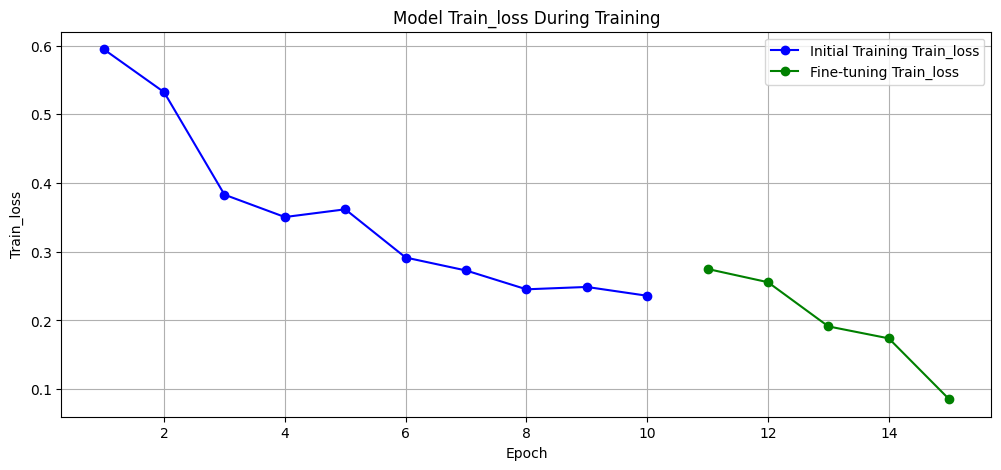

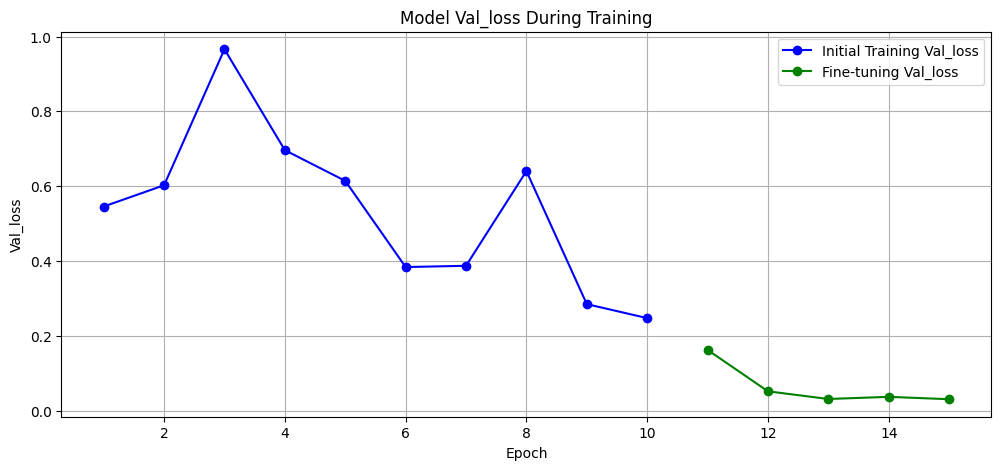

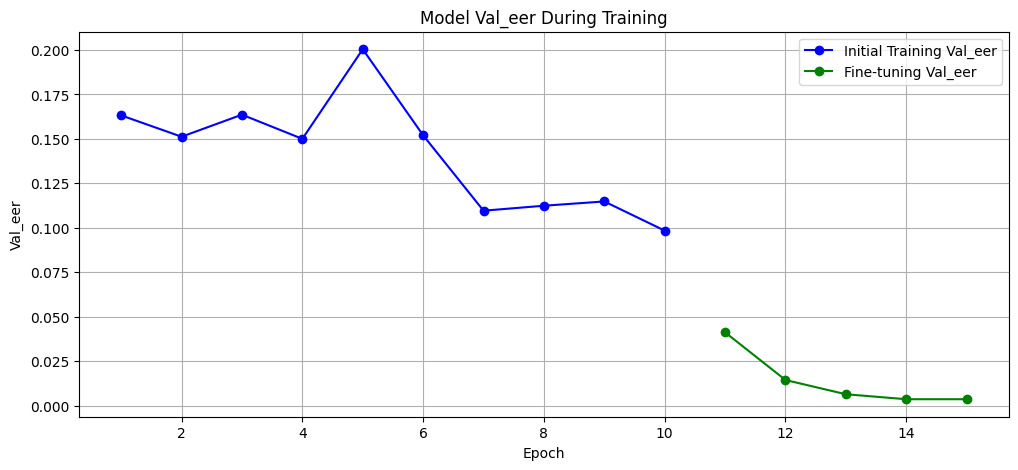

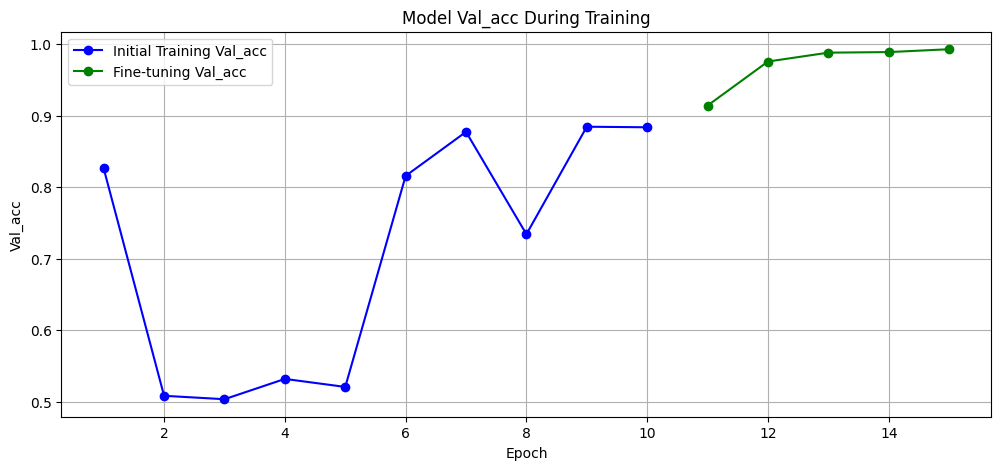


Script finished.


In [47]:

# --- 11. Save the Final Model (Best Fine-tuned State) ---
final_model_filepath = os.path.join(MODEL_SAVE_PATH, FINAL_MODEL_NAME)
torch.save(model.state_dict(), final_model_filepath)
print(f"Final best model state saved at: {final_model_filepath}")

# --- Optional: Plot Training History (Requires matplotlib) ---
try:
    import matplotlib.pyplot as plt

    def plot_combined_history(history_initial, history_fine_tune, metric='loss'):
        """Plots a metric from both initial and fine-tuning phases."""
        plt.figure(figsize=(12, 5))
        total_epochs_initial = len(history_initial.get(metric, []))
        total_epochs_ft = len(history_fine_tune.get(metric, []))
        epochs_initial = range(1, total_epochs_initial + 1)
        if history_initial.get(metric):
            plt.plot(epochs_initial, history_initial[metric], 'bo-', label=f'Initial Training {metric.capitalize()}')
        val_metric = f'val_{metric}'
        if history_initial.get(val_metric):
            plt.plot(epochs_initial, history_initial[val_metric], 'ro-', label=f'Initial Validation {metric.capitalize()}')

        epochs_ft_total = range(total_epochs_initial + 1, total_epochs_initial + total_epochs_ft + 1)
        if history_fine_tune.get(metric):
            plt.plot(epochs_ft_total, history_fine_tune[metric], 'go-', label=f'Fine-tuning {metric.capitalize()}')
        if history_fine_tune.get(val_metric):
             plt.plot(epochs_ft_total, history_fine_tune[val_metric], 'mo-', label=f'Fine-tuning Validation {metric.capitalize()}')

        plt.title(f'Model {metric.capitalize()} During Training')
        plt.xlabel('Epoch')
        plt.ylabel(metric.capitalize())
        handles, labels = plt.gca().get_legend_handles_labels()
        if handles: plt.legend()
        plt.grid(True)
        plt.show()

    print("\nPlotting training history...")
    if history and history_ft: # Check if histories exist
        plot_combined_history(history, history_ft, metric='train_loss')
        plot_combined_history(history, history_ft, metric='val_loss')
        plot_combined_history(history, history_ft, metric='val_eer')
        plot_combined_history(history, history_ft, metric='val_acc')
    else:
        print("Skipping plotting as one or both history objects are missing.")

except ImportError:
    print("\nMatplotlib not found. Skipping history plotting.")
except Exception as e:
    print(f"\nError during plotting: {e}")

print("\nScript finished.")
